### Análisis de datos II
## Clustering
### Estabilidad por Bootstrapping

Ejemplificamos la estabilidad por bootstraping con el modelo GMM y datos sintéticos.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.mixture import GaussianMixture

In [2]:
# Generamos un dataset sintético de ejemplo
from sklearn.datasets import make_blobs

X, _ = make_blobs(n_samples=600, centers=5, cluster_std=2.0, random_state=42)
X.shape

(600, 2)

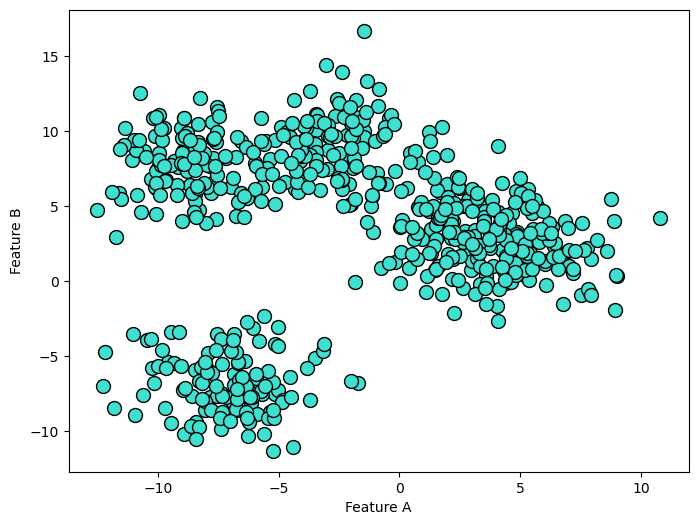

In [3]:
fig, ax = plt.subplots(figsize=(8, 6))
plt.plot(X[:, 0], X[:, 1],
                "o",
                markerfacecolor='turquoise',
                markeredgecolor="k",
                markersize=10)
plt.xlabel("Feature A")
plt.ylabel("Feature B")
plt.show()

#### Entrenamos el modelo GMM.

In [4]:
K = 5
gmm = GaussianMixture(n_components=K, covariance_type='full',random_state=0)
gmm = gmm.fit(X)
labels_base = gmm.predict(X)

#### Comparamos el original vs 3 muestras de bootstrapping

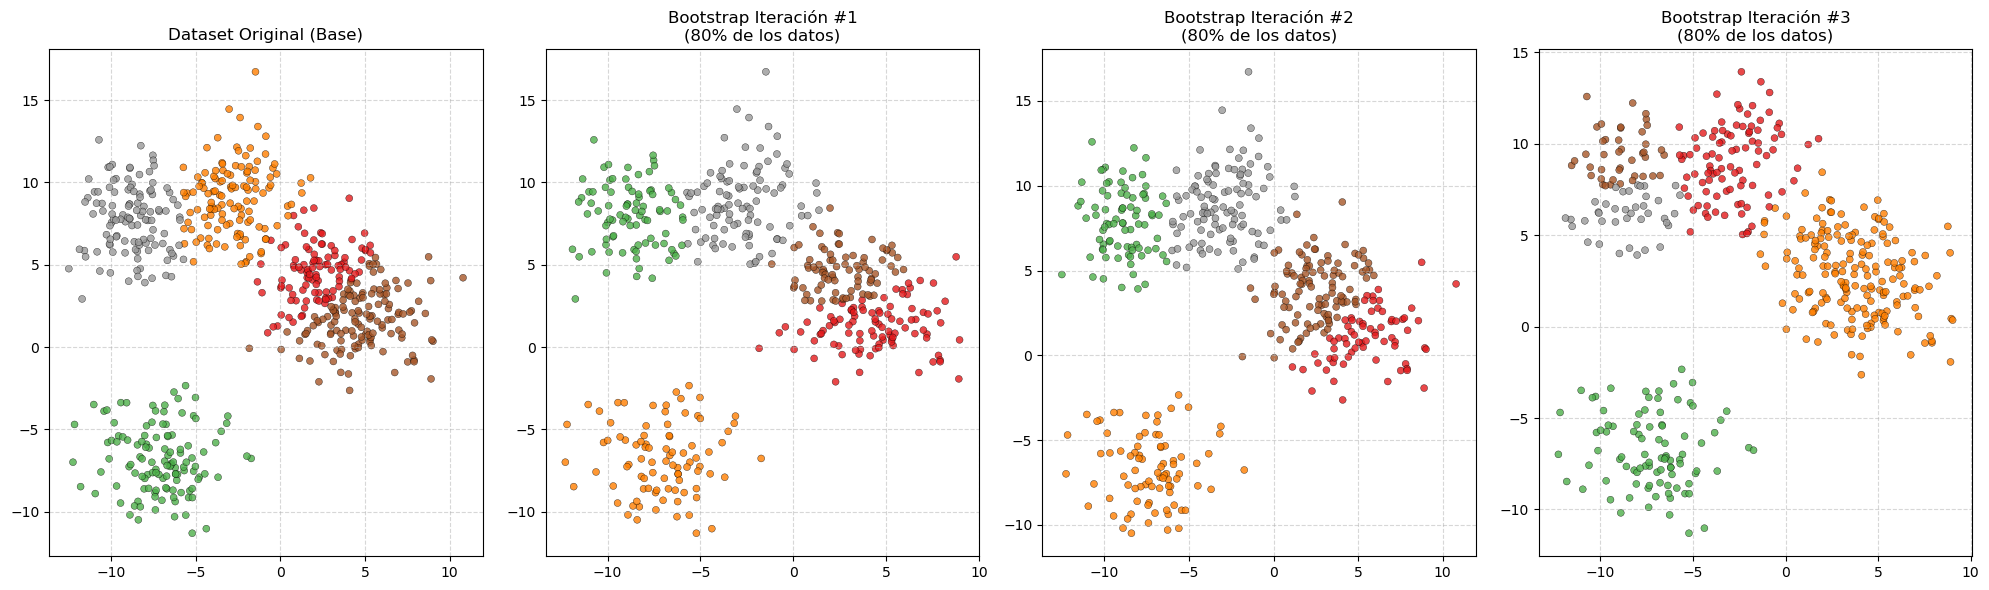

In [5]:
fig, axes = plt.subplots(1, 4, figsize=(20, 6))

# Modelo base original
axes[0].scatter(X[:, 0], X[:, 1], c=labels_base, cmap='Set1', s=25, alpha=0.8, edgecolor='k', linewidth=0.3)

axes[0].set_title("Dataset Original (Base)")
axes[0].grid(True, linestyle='--', alpha=0.5)

# Iteraciones de bootstrapping
for idx, ax in enumerate(axes[1:], start=1):

    indices = np.random.choice(len(X), int(len(X) * 0.75), replace=False) # submuestra aleatoria del 80%
    X_sub = X[indices]

    # Reentrena GMM en la submuestra
    gmm = gmm.fit(X_sub)
    sub_labels = gmm.predict(X_sub)
    
    scatter = ax.scatter(X_sub[:, 0], X_sub[:, 1], c=sub_labels, cmap='Set1', s=25, alpha=0.8, edgecolor='k', linewidth=0.3)
        
    ax.set_title(f"Bootstrap Iteración #{idx}\n(80% de los datos)")
    ax.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

#### Impacto del submuestreo

En cada iteración (paneles de la derecha) faltan puntos (porque sacamos un 20%).

En las itración #3, los clusters cambiaron bastante. En las otras, las fronteras de los clusters se movieron un poco.

---
### Estabilidad por bootstrapping

Vamos a ver cómo se reflejan las observaciones anteriores esto en el cálculo de estabilidad.

Creamos una función para computar la estabilidad de Jaccard y la calculamos estabilidad para el modelo GMM y los datos sintéticos generados.

In [6]:
# Función para computar la estabilidad de Jaccard.
from scipy.optimize import linear_sum_assignment

def compute_jaccard_stability(X, base_labels, n_bootstraps=50, sample_ratio=0.8):
    n_samples = len(X)
    k = len(np.unique(base_labels))
    jaccard_per_cluster = {i: [] for i in range(k)}
    
    for _ in range(n_bootstraps):
        # Toma una submuestra aleatoria (bootstrap / submuestreo sin reposición)
        indices = np.random.choice(n_samples, int(n_samples * sample_ratio), replace=False)
        X_sub = X[indices]
        base_sub_labels = base_labels[indices]
        
        # Reentrena GMM en la submuestra
        g = gmm.fit(X_sub)
        sub_labels = g.predict(X_sub)
        
        # -------------------------------------------------------------------------------------------------
        # Alinea las etiquetas de los clusters (necesaria porque los IDs pueden cambiar en cada iteración)

        # Matriz de contingencia para emparejar los clusters originales con los nuevos
        contingency = np.zeros((k, k))
        for i in range(k):
            for j in range(k):
                contingency[i, j] = np.sum((base_sub_labels == i) & (sub_labels == j))
        
        # Encuentra la mejor correspondencia de etiquetas
        row_ind, col_ind = linear_sum_assignment(-contingency)
        
        # Mapea las etiquetas nuevas a las originales
        mapping = {col: row for row, col in zip(row_ind, col_ind)}
        aligned_sub_labels = np.array([mapping.get(label, -1) for label in sub_labels])
        # -------------------------------------------------------------------------------------------------
    
        # Calcula el índice de Jaccard para cada cluster individualmente en la submuestra
        # El índice de Jaccard mide cuántos puntos de la intersección lograron quedarse en el mismo grupo aunque la muestra haya cambiado.
        
        for i in range(k):
            # Puntos que pertenecían al cluster i en la base original (dentro de la submuestra)
            orig_mask = (base_sub_labels == i)
            # Puntos que terminaron en el cluster i alineado
            new_mask = (aligned_sub_labels == i)
            
            intersection = np.sum(orig_mask & new_mask)
            union = np.sum(orig_mask | new_mask)
            
            if union > 0:
                jaccard = intersection / union
                jaccard_per_cluster[i].append(jaccard)
                
    return jaccard_per_cluster

In [7]:
stability_results = compute_jaccard_stability(X, labels_base, n_bootstraps=50, sample_ratio=0.8)

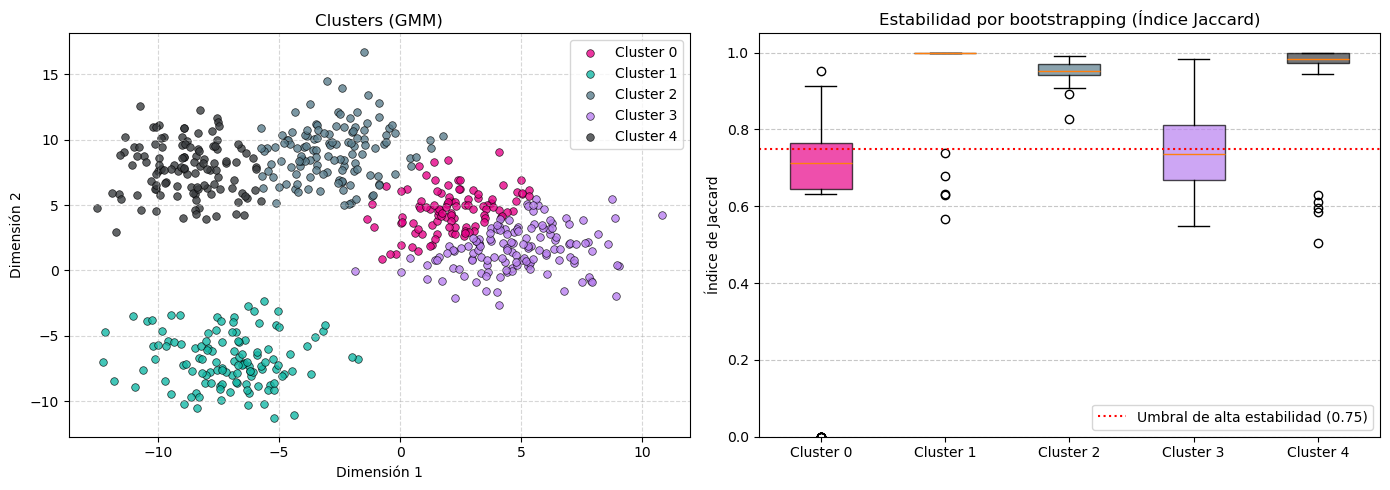

In [8]:
cluster_colors = ["#e70489", "#14b8a6", "#5a7d8c", "#b980f0", "#3a3d40", "#9900ff", "#000000"]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# 1. Panel izquierdo: Resultado del GMM
for i in range(K):
    mask = (labels_base == i)
    ax1.scatter(X[mask, 0], X[mask, 1], color=cluster_colors[i], 
                label=f"Cluster {i}", s=30, alpha=0.8, edgecolor='k', linewidth=0.5)

ax1.set_title("Clusters (GMM)")
ax1.set_xlabel("Dimensión 1")
ax1.set_ylabel("Dimensión 2")
ax1.grid(True, linestyle='--', alpha=0.5)
ax1.legend()

# 2. Panel derecho: Estabilidad por bootstrapping
data_to_plot = [stability_results[i] for i in range(K)]
bp = ax2.boxplot(data_to_plot, tick_labels=[f"Cluster {i}" for i in range(K)], patch_artist=True)

for patch, color in zip(bp['boxes'], cluster_colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)

ax2.set_title("Estabilidad por bootstrapping (Índice Jaccard)")
ax2.set_ylabel("Índice de Jaccard")
ax2.set_ylim(0, 1.05)
ax2.grid(axis='y', linestyle='--', alpha=0.7)
ax2.axhline(y=0.75, color='r', linestyle=':', label='Umbral de alta estabilidad (0.75)')
ax2.legend(loc='lower right')

plt.tight_layout()
plt.show()

**OBSERVACIONES**

En el panel izquierdo (GMM) vemos que los clusters se superponen bastante. En particular, los grupos 0 y 3 no tienen una separación real.

En el panel derecho (Estabilidad) vemos cómo las medianas de estabilidad de estos dos clusters rozan o están por debajo del umbral de seguridad de 0.75, con boxplots grandes.

Esto pasa porque el modelo probabilístico es muy sensible. Al hacer bootstrapping, las estimaciones de las gaussianas se mueven y eso hace que los puntos de la zona de solapamiento cambien de asignación entre una submuestra y otra.

La baja estabilidad en GMM no significa que el algoritmo no fucione; significa que, en este caso, los datos están superpuestos y hay una zona gris donde es imposible separar los grupos con precisión.